# Import Data

In [1]:
import pandas as pd

# Load data yang sudah melewati tahap EDA dan Feature Engineering
DATA_PATH = '../data/'
df = pd.read_csv(DATA_PATH + 'processed_features.csv', low_memory=False)

df.head()

,resultId,raceId,driverId,constructorId,number,grid,position,positionText,positionOrder,points,...,q1_sec,q2_sec,q3_sec,best_qualy_sec,qualy_delta_sec,year,round,prior_points,prior_position,prior_wins
0,1,18,1,1,22,1.0,1,1,1,10.0,...,86.572,85.187,86.714,85.187,0.000,2008,1,0.0,20,0.0
1,2,18,2,2,3,5.0,2,2,2,8.0,...,85.960,85.518,87.236,85.518,0.331,2008,1,0.0,20,0.0
2,3,18,3,3,7,7.0,3,3,3,6.0,...,86.295,86.059,88.687,86.059,0.872,2008,1,0.0,20,0.0
3,4,18,4,4,5,11.0,4,4,4,5.0,...,86.907,86.188,NaN,86.188,1.001,2008,1,0.0,20,0.0
4,5,18,5,1,23,3.0,5,5,5,4.0,...,85.664,85.452,87.079,85.452,0.265,2008,1,0.0,20,0.0


In [2]:
import numpy as np

# 1. Tentukan fitur prediktor (X)
kolom_fitur = [
    'grid', 
    'qualy_delta_sec', 
    'prior_points', 
    'prior_position', 
    'prior_wins',
    'median_gap_leader',
    'std_gap_leader'
]

# --- TAMBALAN ITERATIF MULAI DARI SINI ---
# Ubah \N menjadi NaN, lalu paksa konversi semua kolom fitur menjadi angka murni
for col in kolom_fitur:
    # regex=False penting di sini agar Python membaca string '\N' secara harafiah
    df[col] = pd.to_numeric(df[col].replace(r'\N', np.nan, regex=False), errors='coerce')
# -----------------------------------------

# 2. Buang baris yang memiliki missing values (termasuk \N yang baru saja jadi NaN)
df_model = df.dropna(subset=kolom_fitur).copy()

# 3. Pemisahan Data Berdasarkan Waktu (Temporal Split)
tahun_batas_test = 2023

data_train = df_model[df_model['year'] < tahun_batas_test]
data_test = df_model[df_model['year'] >= tahun_batas_test]

# 4. Pisahkan X (Fitur) dan y (Target)
X_train = data_train[kolom_fitur]
y_train = data_train['is_podium']

X_test = data_test[kolom_fitur]
y_test = data_test['is_podium']

print(f"Jumlah Data Pelatihan (Sebelum {tahun_batas_test}): {len(X_train)} baris")
print(f"Jumlah Data Pengujian ({tahun_batas_test} - Sekarang): {len(X_test)} baris")

Jumlah Data Pelatihan (Sebelum 2023): 9061 baris
Jumlah Data Pengujian (2023 - Sekarang): 1479 baris


# Model

Laporan Evaluasi Model (Classification Report):
              precision    recall  f1-score   support

           0       0.96      0.93      0.94      1248
           1       0.67      0.77      0.72       231

    accuracy                           0.91      1479
   macro avg       0.82      0.85      0.83      1479
weighted avg       0.91      0.91      0.91      1479



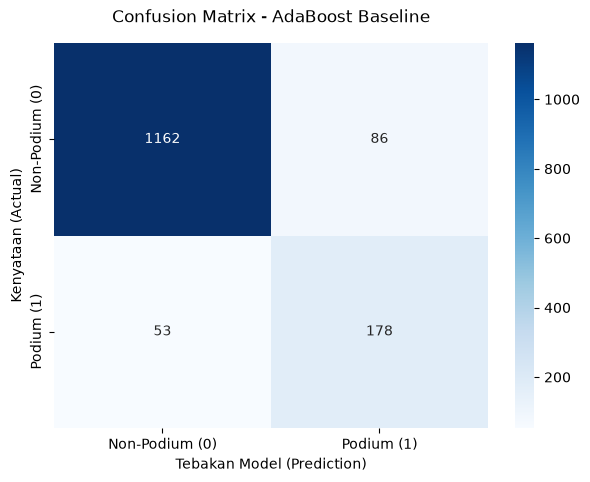

In [3]:
from sklearn.ensemble import AdaBoostClassifier
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

# 1. Inisialisasi dan Pelatihan Model
# Menggunakan 50 decision trees (n_estimators) sebagai baseline awal
model_clf = AdaBoostClassifier(n_estimators=50, random_state=42)
model_clf.fit(X_train, y_train)

# 2. Eksekusi Prediksi pada Data Uji (Tahun 2023 - Sekarang)
y_pred = model_clf.predict(X_test)

# 3. Evaluasi Metrik Klasifikasi
print("Laporan Evaluasi Model (Classification Report):")
print(classification_report(y_test, y_pred))

# 4. Visualisasi Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(7, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Non-Podium (0)', 'Podium (1)'],
            yticklabels=['Non-Podium (0)', 'Podium (1)'])
plt.ylabel('Kenyataan (Actual)')
plt.xlabel('Tebakan Model (Prediction)')
plt.title('Confusion Matrix - AdaBoost Baseline', pad=15)
plt.show()